In [ ]:
import os

import numpy as np
import torch
import matplotlib.pyplot as plt
import cv2

import imageio

import gc

from segment_anything import sam_model_registry, SamAutomaticMaskGenerator
from scipy.ndimage import rotate
from scipy.optimize import minimize

In [ ]:
MAX_IMAGE_SIZE = 3000000
# maximum number of pixels we authorize for an image
# (lower this in case of GPUOutOfMemory error)

In [27]:
def list_directory_contents(directory):
    """return a list of all directories and folder inside directory"""
    pictures_list = []

    try:
        with os.scandir(directory) as entries:
            for entry in entries:
                pictures_list.append(entry.name)

    except FileNotFoundError:
        print(f"The directory {directory} does not exist.")
    except NotADirectoryError:
        print(f"{directory} is not a directory.")
    except PermissionError:
        print(f"Permission denied to access {directory}.")
        
    return pictures_list


def list_files(startpath, exclude="Vrac"):
    """From a stratpath this function list all files with full directory
    We allow to exclude one folder (can be easily adapted to several)"""
    file_list = []
    for root, dirs, files in os.walk(startpath):
        if not exclude in root:
            for file in files:
                file_list.append(os.path.join(root, file))
    return file_list


def get_device():
    if torch.cuda.is_available():
        return torch.device("cuda")
    return torch.device("cpu")

In [ ]:
#useful functions for section 1

def Find_bbox(mask):
    """return x_min,y_min,x_max,y_max for the mask"""
    mask = np.array(mask,dtype = np.uint8)
    mask_coords = np.argwhere(mask == 1)
    xmin,ymin,xmax,ymax = np.min(mask_coords[:,0]),np.min(mask_coords[:,1]),np.max(mask_coords[:,0]),np.max(mask_coords[:,1])
    return xmin,ymin,xmax,ymax

def Rotation_matrix(theta):

    return np.array([[np.cos(theta), -np.sin(theta)],
                     [np.sin(theta), np.cos(theta)]])


def Find_Optimal_Rotation(mask):

    mask = np.array(mask,dtype = np.uint8)

    where_array = np.argwhere(mask == 1)

    def objective_function(theta):
        R_m = Rotation_matrix(theta)
        rotated_mask_coordinates = np.dot(where_array,R_m)
        xmin,ymin,xmax,ymax = np.min(rotated_mask_coordinates[:,0]),np.min(rotated_mask_coordinates[:,1]),np.max(rotated_mask_coordinates[:,0]),np.max(rotated_mask_coordinates[:,1])
        width = ymax - ymin
        height = xmax - xmin
        return -width/height
    
    result = minimize(objective_function,x0 = 0.0,method='BFGS',tol = 0.0001)
    best_angle = np.squeeze(result.x,axis = 0)
    best_ratio = np.abs(result.fun)
    return best_angle,best_ratio

def Universal_crop_reshaper(wing_picture,wing_mask,red_factor,mode='crop',goal_shape = (256,512)):
    """return the reshape crop of wing with boundarie adjustment to fit goal_shape
     without any deformations """
    xmin_i,ymin_i,xmax_i,ymax_i = Find_bbox(wing_mask)
    x,y = goal_shape  

    ratio_ini = (ymax_i-ymin_i)/(xmax_i-xmin_i)
    ratio_f = y/x

    xir,yir,_ = wing_picture.shape

    if ratio_f > ratio_ini:
        ymin_f = int(max(0,(ymax_i+ymin_i)/2-ratio_f/ratio_ini*(ymax_i-ymin_i)/2))
        ymax_f = int(ymin_f + (ymax_i-ymin_i)*ratio_f/ratio_ini)
        xmin_f,xmax_f  = xmin_i,xmax_i
    else:
        xmin_f = int(max(0,(xmax_i+xmin_i)/2-ratio_ini/ratio_f*(xmax_i-xmin_i)/2))
        xmax_f = int(xmin_f + (xmax_i-xmin_i)*ratio_ini/ratio_f)
        ymin_f,ymax_f  = ymin_i,ymax_i

    xmin_f,xmax_f,ymin_f,ymax_f = int(xmin_f*red_factor),int(xmax_f*red_factor),int(ymin_f*red_factor),int(ymax_f*red_factor)
    
    if mode == 'crop':
        cropped_wing = wing_picture[xmin_f:xmax_f,ymin_f:ymax_f]
        resized_cropped_wing = cv2.resize(cropped_wing,(y,x),interpolation = cv2.INTER_LINEAR)
        return resized_cropped_wing, [xmin_f,xmax_f,ymin_f,ymax_f]
    
    elif mode == 'seg':
        extended_effective_mask = cv2.resize(wing_mask,(yir,xir),interpolation = cv2.INTER_LINEAR)
        extended_effective_mask = np.expand_dims(extended_effective_mask,axis = 2).astype(np.float32)
        segmented_cropped_wing = (wing_picture[xmin_f:xmax_f,ymin_f:ymax_f]*extended_effective_mask[xmin_f:xmax_f,ymin_f:ymax_f]).astype(np.uint8)
        resized_seg_wing = cv2.resize(segmented_cropped_wing,(y,x))
        return resized_seg_wing

def segment_and_crop(wing_image,option = 'C'):
    """this function take image with wing and white background
      as argument and return segmented and cropped wing as np array
      """
    gc.collect()
    torch.cuda.empty_cache()  #clear gpu memory (don' t know if it's really useful)
    
    xi,yi,zi = wing_image.shape
    reduction_factor = max(1,(xi*yi/MAX_IMAGE_SIZE)**(1/2)) 
    #the parameter above is necessary, because some images are too big, and this cause issues for SAM inference
    image_r = cv2.resize(wing_image, (int(yi/reduction_factor), int(xi/reduction_factor)),interpolation = cv2.INTER_LINEAR)

    # Generate masks
    with torch.no_grad():
        masks = mask_generator.generate(image_r) #generating masks

    current_max_area = 0   #this will store the current area of the object that verify the condition below : the goal is to extract the largest one that respect that condition
    wing_mask = None
    effective_best_rotation = 0 #in case something went wrong, we set default best rotation to 0
    effective_best_ratio = None

    #thanks to the parameters set for AutomaticMaskGenerator, we don't need a filter for largest connected component
    #we however have to compute the rotation that maximize width/height factor, to use this to discriminate masks
    #this will be then used to rotate wings
    


    for mask in masks:
        effective_mask = np.array(mask['segmentation'],dtype = np.uint8)
        best_rotation,best_ratio = Find_Optimal_Rotation(effective_mask)

        if 2.2<best_ratio<2.8: #parameters set empirically
            if mask['area'] > current_max_area:
                effective_best_rotation = best_rotation
                effective_best_ratio = best_ratio #this variable is never used
                wing_mask = mask
                current_max_area = mask['area'] #update current_max_area value


    effective_best_rotation = effective_best_rotation  * 180/np.pi #conversion to degree
    effective_mask = rotate(np.array(wing_mask['segmentation'],dtype = np.float32),angle=effective_best_rotation,reshape = True)
    effective_mask = np.round(effective_mask).astype(np.uint8)
   
    wing_image_rotated = rotate(wing_image,angle=effective_best_rotation,reshape = True)



    cropped_rotated_wing,bbox = Universal_crop_reshaper(wing_image_rotated,effective_mask,reduction_factor)
    segmented_rotated_wing = Universal_crop_reshaper(wing_image_rotated,effective_mask,reduction_factor,mode='seg')

    return cropped_rotated_wing,segmented_rotated_wing,effective_best_rotation,bbox

In [28]:
get_device()

device(type='cpu')

In [12]:
def show_anns(anns):
    if len(anns) == 0:
        return
    sorted_anns = sorted(anns, key=(lambda x: x['area']), reverse=True)
    ax = plt.gca()
    ax.set_autoscale_on(False)

    img = np.ones((sorted_anns[0]['segmentation'].shape[0], sorted_anns[0]['segmentation'].shape[1], 4))
    img[:,:,3] = 0
    for ann in sorted_anns:
        m = ann['segmentation']
        color_mask = np.concatenate([np.random.random(3), [0.35]])
        img[m] = color_mask
    ax.imshow(img)

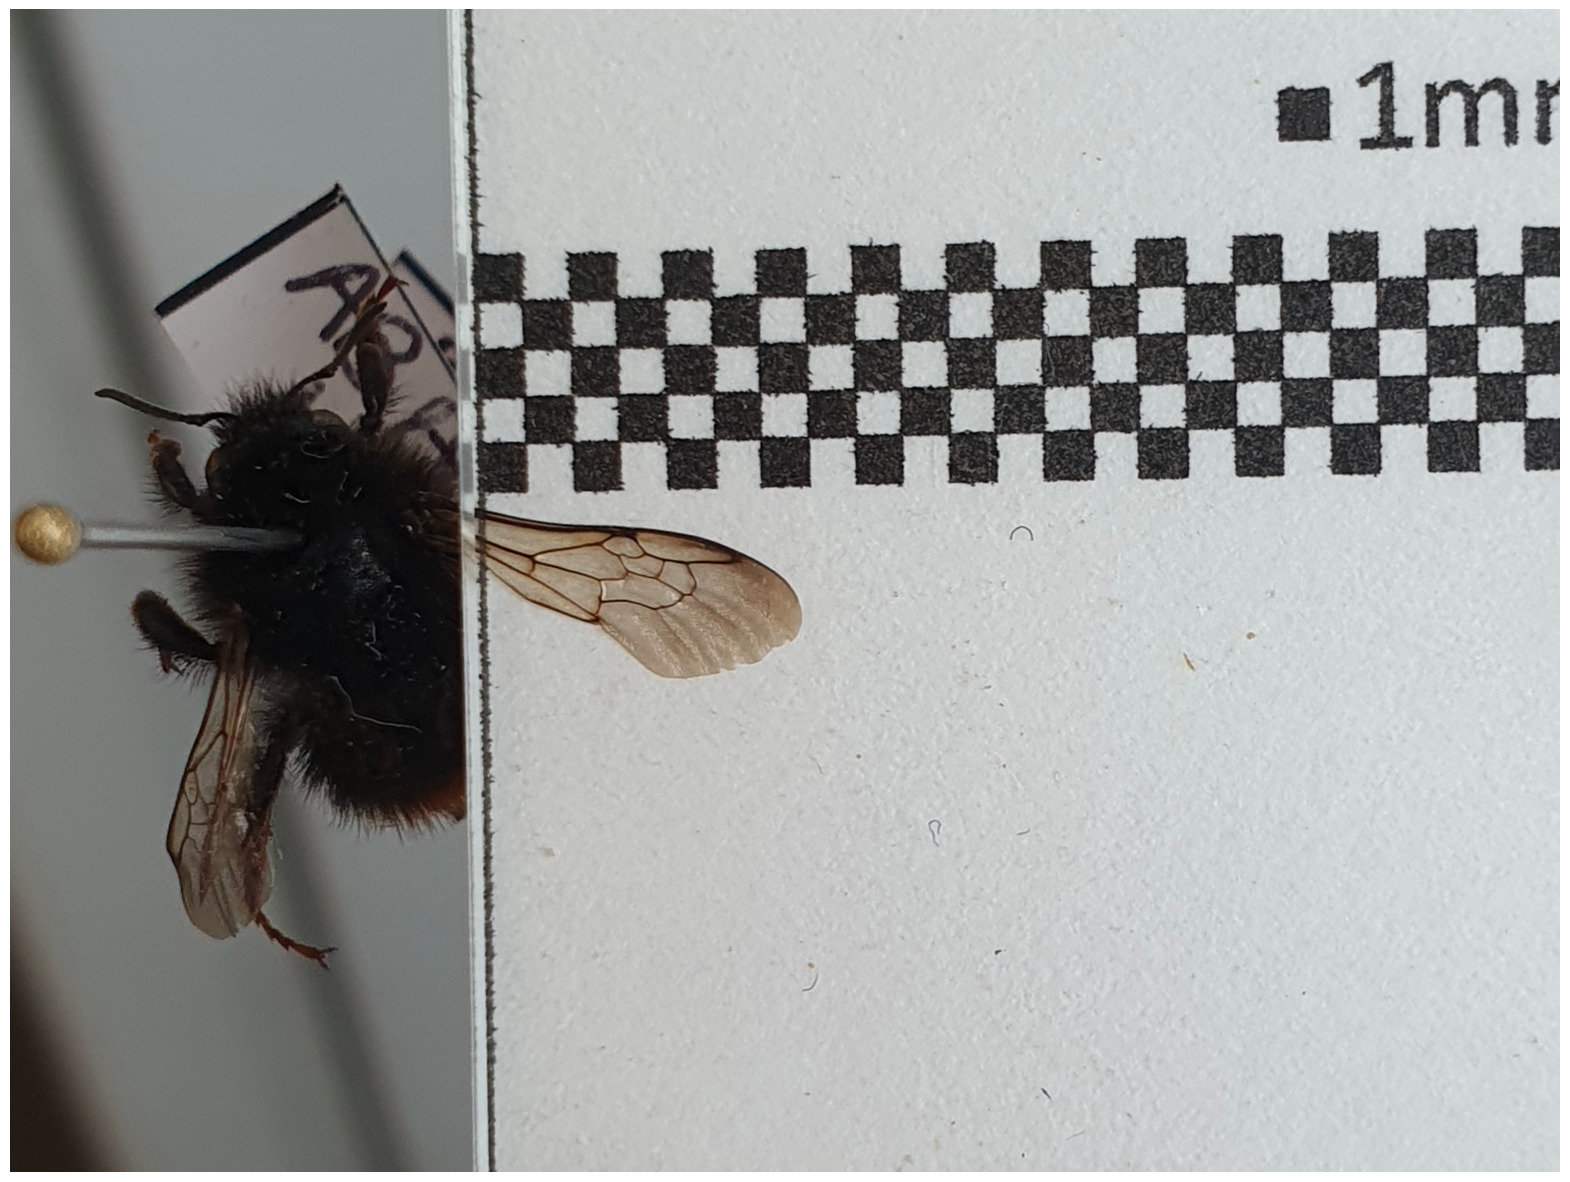

In [49]:
# image = cv2.imread('../data/images/orga_cropping/Bombus_confusus/male/FR15_ABOM080820007_P1.JPG')
# image = cv2.imread('../data/images/orga_widecrop/Bombus_confusus/male/FR15_ABOM080820007_P1.JPG')
image = cv2.imread('../data/images/orga_widecrop/Bombus_ruderarius/worker/ABAURA4902_S3.jpg')
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(20,20))
plt.imshow(image)
plt.axis('off')
plt.show()

## Automatic mask generation

In [29]:
checkpoint = "../data/models/sam/sam_vit_l_0b3195.pth"
model_type = "vit_l" 

device = get_device()

sam = sam_model_registry[model_type](checkpoint=checkpoint)
sam.to(device)

mask_generator = SamAutomaticMaskGenerator(sam, min_mask_region_area=5000)
# the second parameter stand to avoid masks with several connected components with one of them to small to be a wing
# he might be ajusted if your dataset have very high quality or very low quality

In [ ]:
def debug_masks(image_r, masks, ratio_min=2.2, ratio_max=2.8):
    """Affiche chaque masque produit par SAM avec son aire et son ratio 
    d'élongation optimal, pour voir pourquoi il est gardé ou rejeté."""
    print(f"{len(masks)} masques générés par SAM")

    infos = []
    for i, mask in enumerate(masks):
        seg = np.array(mask['segmentation'], dtype=np.uint8)
        angle, ratio = Find_Optimal_Rotation(seg)
        passes = ratio_min < ratio < ratio_max
        infos.append((i, mask, angle, ratio, passes))

    infos.sort(key=lambda t: -t[1]['area'])

    n = min(len(infos), 8)
    fig, axes = plt.subplots(1, n, figsize=(4*n, 4))
    if n == 1:
        axes = [axes]

    for ax, (i, mask, angle, ratio, passes) in zip(axes, infos[:n]):
        ax.imshow(image_r)
        ax.imshow(mask['segmentation'], alpha=0.5, cmap='autumn')
        ax.set_title(f"aire={mask['area']}\nratio={ratio:.2f}\n{'✓ gardé' if passes else '✗ rejeté'}")
        ax.axis('off')
    plt.tight_layout()
    plt.show()

    for i, mask, angle, ratio, passes in infos:
        flag = "✓ VALIDE" if passes else "✗ rejeté"
        print(f"masque {i:2d} | aire={mask['area']:7d} | ratio={ratio:5.2f} | {flag}")

    return infos

In [52]:
masks = mask_generator.generate(image)

116 masques générés par SAM


AttributeError: 'numpy.ndarray' object has no attribute 'imshow'

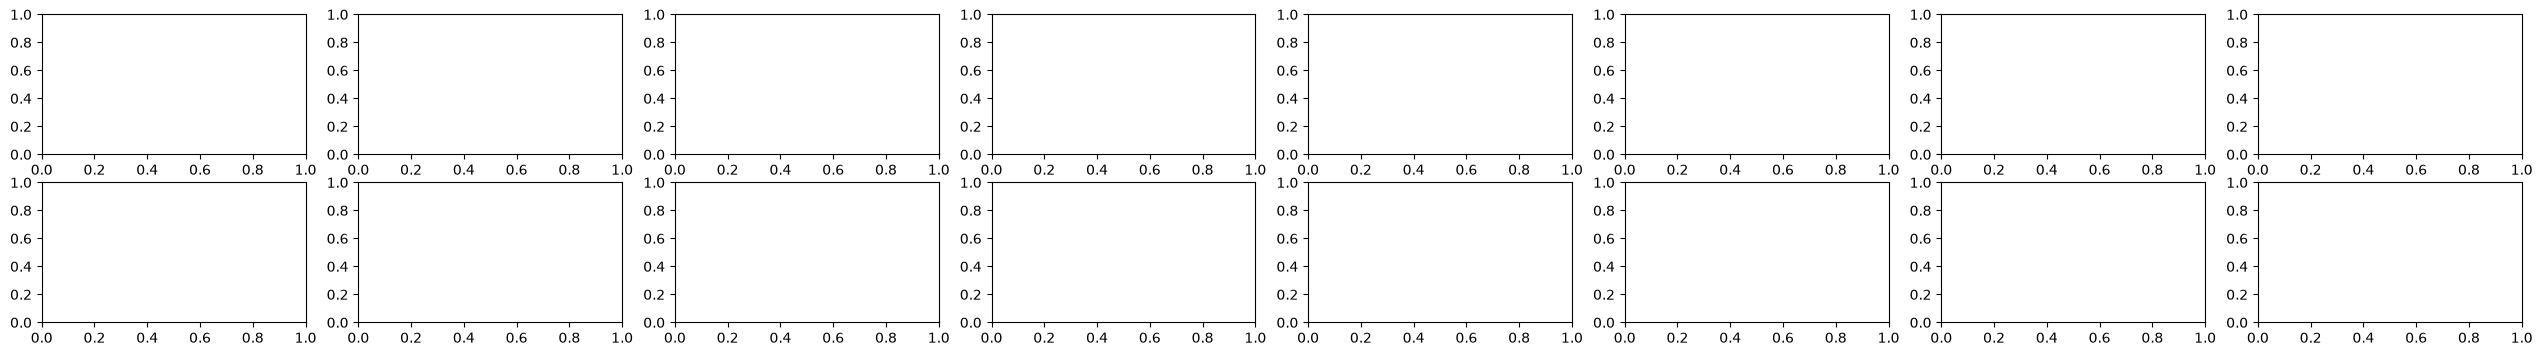

In [57]:
infos = debug_masks(image, masks)

In [37]:
def segment_wings(wing_image, ratio_min=2.2, ratio_max=2.8, max_wings=2, verbose=False):
    """Version robuste : retourne une LISTE de résultats (un par aile détectée)
    au lieu de planter s'il y a 0 aile valide, et sans en perdre s'il y en a 2."""
    gc.collect()
    torch.cuda.empty_cache()

    xi, yi, zi = wing_image.shape
    reduction_factor = max(1, (xi*yi/MAX_IMAGE_SIZE)**0.5)
    image_r = cv2.resize(wing_image, (int(yi/reduction_factor), int(xi/reduction_factor)),
                          interpolation=cv2.INTER_LINEAR)

    with torch.no_grad():
        masks = mask_generator.generate(image_r)

    # 1) on garde TOUS les masques qui passent le filtre, pas juste le meilleur
    candidates = []
    for mask in masks:
        seg = np.array(mask['segmentation'], dtype=np.uint8)
        angle, ratio = Find_Optimal_Rotation(seg)
        if ratio_min < ratio < ratio_max:
            candidates.append({'mask': mask, 'angle': angle, 'ratio': ratio, 'area': mask['area']})

    if verbose:
        print(f"{len(masks)} masques générés, {len(candidates)} passent le filtre d'élongation")

    if not candidates:
        if verbose:
            print("Aucune aile détectée sur cette image (filtre trop strict, ailes fusionnées, ou mauvaise qualité).")
        return []

    # 2) on évite de compter 2x le même objet si SAM le propose en double
    candidates.sort(key=lambda c: -c['area'])
    kept = []
    for c in candidates:
        seg = np.array(c['mask']['segmentation'], dtype=bool)
        if any(
            np.logical_and(seg, np.array(k['mask']['segmentation'], dtype=bool)).sum()
            / max(1, np.logical_or(seg, np.array(k['mask']['segmentation'], dtype=bool)).sum())
            > 0.5
            for k in kept
        ):
            continue
        kept.append(c)
        if len(kept) >= max_wings:
            break

    # 3) rotation + crop pour chaque aile gardée (logique inchangée de Gabriel)
    results = []
    for c in kept:
        rot_deg = c['angle'] * 180/np.pi
        effective_mask = rotate(np.array(c['mask']['segmentation'], dtype=np.float32),
                                 angle=rot_deg, reshape=True)
        effective_mask = np.round(effective_mask).astype(np.uint8)
        wing_image_rotated = rotate(wing_image, angle=rot_deg, reshape=True)

        crop, bbox = Universal_crop_reshaper(wing_image_rotated, effective_mask, reduction_factor)
        seg_crop = Universal_crop_reshaper(wing_image_rotated, effective_mask, reduction_factor, mode='seg')

        results.append({'crop': crop, 'seg': seg_crop, 'angle': rot_deg,
                         'bbox': bbox, 'area': c['area'], 'ratio': c['ratio']})

    return results  # trié par aire décroissante : results[0] = l'aile la plus grande

In [51]:
for idx, wing in enumerate(segment_wings(image, verbose=True)):
    imageio.imwrite(f'../out/crop/test_{idx}.png', wing['crop'])
    imageio.imwrite(f'../out/seg/test_{idx}.png', wing['seg'])

119 masques générés, 6 passent le filtre d'élongation


In [31]:
print(len(masks))
print(masks[0].keys())

35
dict_keys(['segmentation', 'area', 'bbox', 'predicted_iou', 'point_coords', 'stability_score', 'crop_box'])


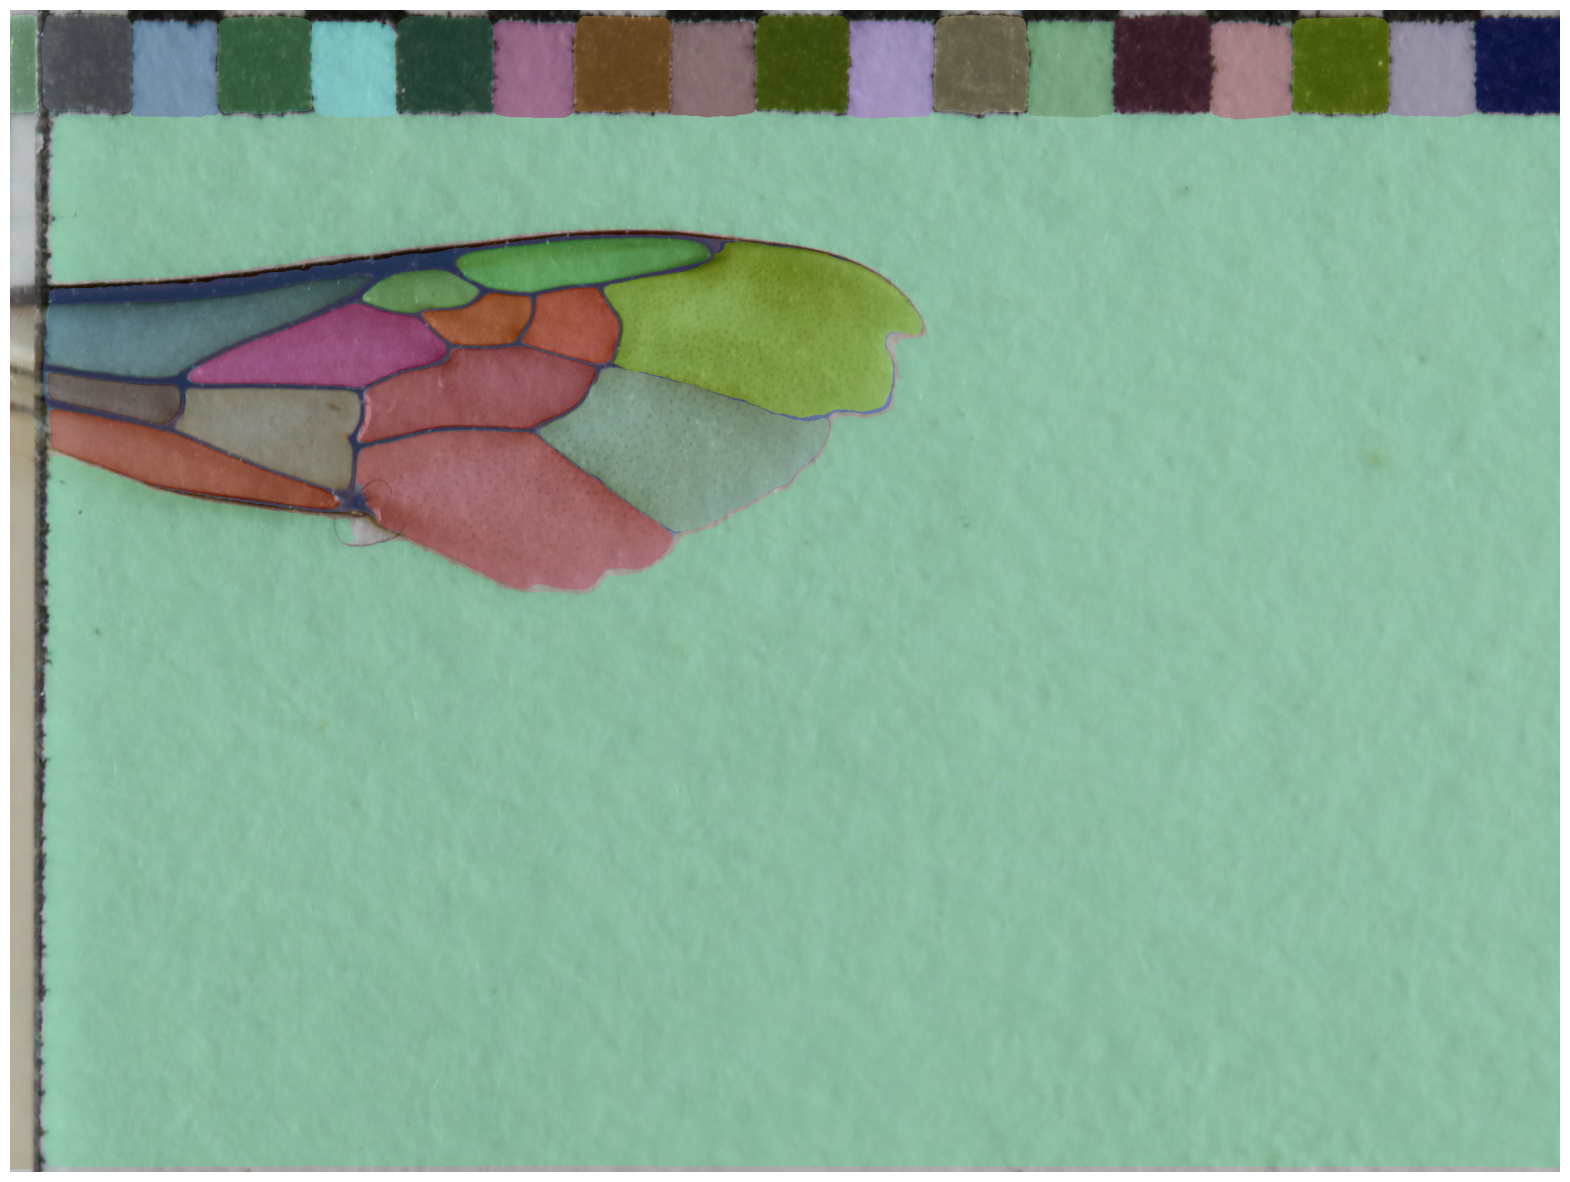

In [32]:
plt.figure(figsize=(20,20))
plt.imshow(image)
show_anns(masks)
plt.axis('off')
plt.show() 